Load Dataset

In [8]:
import kagglehub

# Download latest version

path = kagglehub.dataset_download(
    "abuzarkhaaan/helmetandguntesting",
    output_dir=r"C:\kaggle"
)
# or
# path = kagglehub.dataset_download("abuzarkhaaan/helmetandguntesting")
path = path + "/Gun with webcam views.v1i.yolov8"

print("Path to dataset files:", path)

Path to dataset files: C:\kaggle/Gun with webcam views.v1i.yolov8


In [9]:
from scipy.sparse import data
import os
import json
import time
import yaml
from pathlib import Path
from statistics import mean, stdev
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def test_model_metrics(model_path, dataset, conf=0.28, save_json_path=None):
    # Cargar modelo
    model = YOLO(model_path)

    test_images_path = dataset + "/test/images"
    test_labels_path = dataset + "/test/labels"

    # Obtener lista de archivos de imágenes
    image_files = sorted([
        f for f in os.listdir(test_images_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    y_true = []
    y_pred = []
    latencies_ms = []

    for img_file in image_files:
        img_path = os.path.join(test_images_path, img_file)

        stem = Path(img_file).stem
        label_path = os.path.join(test_labels_path, stem + ".txt")

        # Ground truth por imagen:
        # 1 = hay al menos un objeto anotado
        # 0 = no hay objetos anotados
        has_object = os.path.exists(label_path) and os.path.getsize(label_path) > 0
        if has_object:
          y_true.append(1)
        else:
          y_true.append(0)

        # Predicción con el threshold real del sistema
        start = time.perf_counter()
        results = model.predict(img_path, conf=conf, verbose=False)
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000.0)

        boxes = results[0].boxes
        pred_has_object = boxes is not None and len(boxes) > 0
        if pred_has_object:
          y_pred.append(1)
        else:
          y_pred.append(0)

    # Métricas por imagen
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    avg_latency = mean(latencies_ms) if latencies_ms else 0.0
    std_latency = stdev(latencies_ms) if len(latencies_ms) > 1 else 0.0

    results_dict = {
        "model_path": model_path,
        "dataset": dataset,
        "test_images_path": test_images_path,
        "test_labels_path": test_labels_path,
        "confidence_threshold": conf,
        "num_test_images": len(image_files),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "avg_latency_ms": avg_latency,
        "std_latency_ms": std_latency,
    }

    print("\nSYSTEM-LEVEL TEST METRICS")
    print(f"Test images:        {len(image_files)}")
    print(f"Confidence:         {conf}")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Precision:          {precision:.4f}")
    print(f"Recall:             {recall:.4f}")
    print(f"F1 Score:           {f1:.4f}")
    print(f"Avg latency (ms):   {avg_latency:.2f}")
    print(f"Std latency (ms):   {std_latency:.2f}")

    if save_json_path:
        save_json_path = Path(save_json_path)
        save_json_path.parent.mkdir(parents=True, exist_ok=True)
        with open(save_json_path, "w") as f:
            json.dump(results_dict, f, indent=4)
        print(f"\nJSON guardado en: {save_json_path}")

    return results_dict

In [10]:
import pandas as pd

def find_best_conf(model_path, dataset, conf_values=None, save_csv_path=None):
    if conf_values is None:
        conf_values = [round(x, 2) for x in [i / 100 for i in range(5, 55, 1)]]
        # 0.05 a 0.54

    all_results = []

    for conf in conf_values:
        metrics = test_model_metrics(
            model_path=model_path,
            dataset=dataset,
            conf=conf,
            save_json_path=None
        )

        all_results.append({
            "conf": conf,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "avg_latency_ms": metrics["avg_latency_ms"],
            "std_latency_ms": metrics["std_latency_ms"],
        })

    df = pd.DataFrame(all_results)

    # Mejor conf based on F1
    best_row = df.loc[df["f1_score"].idxmax()]

    print("\nBEST CONF BY F1")
    print("----------------------")
    print(best_row)

    if save_csv_path:
        df.to_csv(save_csv_path, index=False)
        print(f"\nCSV guardado en: {save_csv_path}")

    return df, best_row

In [11]:
MODEL_PATH = "yolov11n/best.onnx"
DATASET = path

df_conf, best_conf_row = find_best_conf(
    model_path=MODEL_PATH,
    dataset=DATASET,
    save_csv_path="yolov11n/conf_results.csv"    # modificar por modelo
)

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading yolov11n/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider

SYSTEM-LEVEL TEST METRICS
Test images:        240
Confidence:         0.05
Accuracy:           0.8667
Precision:          0.9259
Recall:             0.8065
F1 Score:           0.8621
Avg latency (ms):   72.09
Std latency (ms):   10.10
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading yolov11n/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider

SYSTEM-LEVEL TEST METRICS
Test images:        240
Confidence:         0.06
Accuracy:           0.8708
Precision:          0.9346
Recall:             0.8065
F1 Score:           0.8658
Avg latency (ms): 

In [ ]:
from datetime import datetime

def best_conf_with_precision_constraint(df, min_precision=0.95, save_txt_path=None):
    filtered = df[df["precision"] >= min_precision].copy()

    if filtered.empty:
        print("No hay thresholds que cumplan la precision mínima.")
        return None

    best_row = filtered.loc[filtered["f1_score"].idxmax()]

    print(f"\nBEST CONF WITH PRECISION >= {min_precision}")
    print("-------------------------------------")
    print(best_row)

    txt_content = (
        f"Best Confidence Threshold Selection\n"
        f"-------------------------------------\n"
        f"Timestamp: {datetime.now()}\n\n"
        f"Constraint:\n"
        f"  Minimum Precision: {min_precision}\n\n"
        f"Selected Threshold:\n"
        f"  Confidence: {best_row['conf']:.4f}\n\n"
        f"Metrics:\n"
        f"  Accuracy:   {best_row['accuracy']:.4f}\n"
        f"  Precision:  {best_row['precision']:.4f}\n"
        f"  Recall:     {best_row['recall']:.4f}\n"
        f"  F1 Score:   {best_row['f1_score']:.4f}\n"
        f"  Avg Latency (ms): {best_row['avg_latency_ms']:.2f}\n"
        f"  Std Latency (ms): {best_row['std_latency_ms']:.2f}\n"
    )

    if save_txt_path:
        save_txt_path = Path(save_txt_path)
        save_txt_path.parent.mkdir(parents=True, exist_ok=True)

        with open(save_txt_path, "w") as f:
            f.write(txt_content)

    return best_row

best_safe_conf = best_conf_with_precision_constraint(
    df_conf, 
    min_precision=0.95, 
    save_txt_path="yolov11n/best_conf_precision_constraint.txt"     # modificar por modelo
)


BEST CONF WITH PRECISION >= 0.95
-------------------------------------
conf               0.070000
accuracy           0.879167
precision          0.952381
recall             0.806452
f1_score           0.873362
avg_latency_ms    69.412484
std_latency_ms     7.426916
Name: 2, dtype: float64


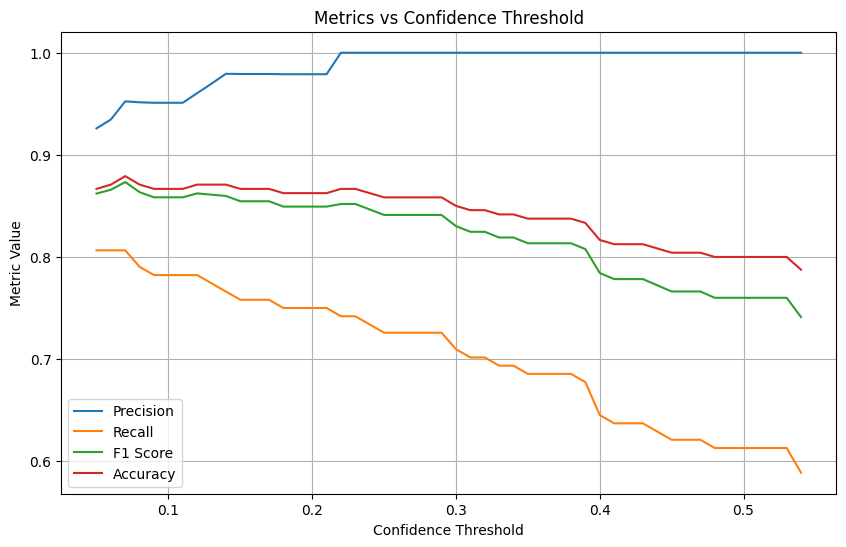

In [17]:
import matplotlib.pyplot as plt

def plot_conf_metrics(df):
    plt.figure(figsize=(10, 6))
    plt.plot(df["conf"], df["precision"], label="Precision")
    plt.plot(df["conf"], df["recall"], label="Recall")
    plt.plot(df["conf"], df["f1_score"], label="F1 Score")
    plt.plot(df["conf"], df["accuracy"], label="Accuracy")
    plt.xlabel("Confidence Threshold")
    plt.ylabel("Metric Value")
    plt.title("Metrics vs Confidence Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_conf_metrics(df_conf)